# ***Ⅱ. 텍스트 데이터 처리***

## ***2. 텍스트 자료의 정보추출***
- 텍스트로부터 유용한 정보를 추출하는 방법에 대해 알아봅니다
- 단어 빈도수: 지난주까지 진행한 내용입니다
- 이번주에는 아래 내용을 중심으로 알아봅니다
    - 문서 빈도수
    - 상대 도수
    - 역문서 빈도수
    - TF-IDF

### ***단어 빈도수 (Term Frequency, TF)***
- 특정 단어가 문서 안에서 몇 번 등장했는지 세어 벡터로 표현
- 예: 음식 리뷰 8개에서 음식별 언급 횟수

    $
    \vec{v} = \sum_{i=1}^{8} \text{review}_i = (4, 8, 3, 5, 0)
    $

### ***문서 빈도수 (Document Frequency, DF)***
- 단어가 몇 개 문서에 등장했는지 세는 값
    $
    DF(\text{짜장면}) = 4
    $


### ***상대 도수 (DF/N, Relative Frequency)***
- 어떤 범주(단어, 음식, 감정 등)가 전체에서 차지하는 비율
    $
    \vec{v}_{rel} = \frac{\vec{v}}{\sum \vec{v}} = \left(\frac{4}{20}, \frac{8}{20}, \frac{3}{20}, \frac{5}{20}, \frac{0}{20}\right) = (0.2, 0.4, 0.15, 0.25, 0)
    $


### ***역문서 빈도수 (Inverse Document Frequency, IDF)***
- 흔한 단어를 무시하고, 희귀 단어를 강조
    $
    IDF(t) = \log\frac{N}{DF(t)}
    $
        N : 전체 문서 수, DF(t) : 단어 t가 등장한 문서 수

### ***TF-IDF(TF x IDF)***
- 흔한 단어를 무시하고, 희귀 단어를 강조
    $
    TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t)
    $

## ***문서 빈도수 벡터***

- **문서 빈도수(DF):** 특정 단어(음식)가 등장한 **문서(리뷰)의 수**  
- 음식 리뷰 8개를 기준으로 DF를 계산합니다.

### ***리뷰 예시***
```plaintext
리뷰 1: "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요"
리뷰 2: "짬뽕이 최고였어요"
리뷰 3: "짜장면도 좋고 짬뽕도 맛있었어요"
리뷰 4: "짬뽕이 맛있고 탕수육도 괜찮았어요"
리뷰 5: "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요"
리뷰 6: "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요"
리뷰 7: "짬뽕과 탕수육 먹었어요"
리뷰 8: "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
```

### ***문서 빈도수 계산***
- 짜장면: 리뷰 1, 3, 5, 6 → 4개 문서  
- 짬뽕: 리뷰 1, 2, 3, 4, 5, 6, 7, 8 → 8개 문서  
- 볶음밥: 리뷰 1, 6, 8 → 3개 문서  
- 탕수육: 리뷰 1, 4, 5, 6, 7, 8 → 6개 문서  
- 양장피: 등장 없음 → 0개 문서  

    $
    DF = (4, 8, 3, 6, 0)
    $

---

### ***해석***
- 문서 빈도수는 **단순히 등장한 리뷰의 수**를 나타냅니다.  
- 상대도수와 달리 **횟수 무시, 등장 여부만 고려**  
- 이후 TF-IDF 계산에 사용됩니다.

    $
    DF(\text{짜장면}) = 4, \quad
    DF(\text{짬뽕}) = 8, \quad
    DF(\text{볶음밥}) = 3, \quad
    DF(\text{탕수육}) = 6, \quad
    DF(\text{양장피}) = 0
    $

문서 빈도수 벡터 (DF): [4 8 3 6 0]


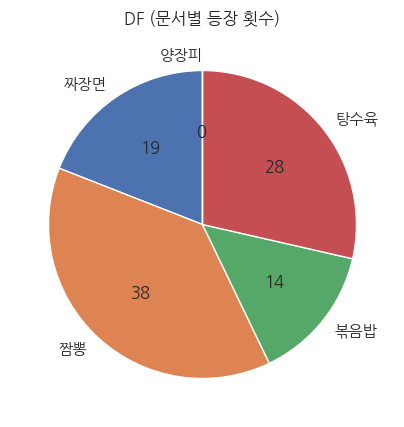

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import re

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')

# 리뷰 8개
reviews = [
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕이 최고였어요",
    "짜장면도 좋고 짬뽕도 맛있었어요",
    "짬뽕이 맛있고 탕수육도 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요",
    "짬뽕과 탕수육 먹었어요",
    "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
]

# 음식 종류
foods = ["짜장면", "짬뽕", "볶음밥", "탕수육", "양장피"]

def document_frequency(reviews, foods):
    df = []
    for food in foods:
        count = sum(1 if re.search(food, review) else 0 for review in reviews)
        df.append(count)
    return np.array(df)

DF = document_frequency(reviews, foods)
print("문서 빈도수 벡터 (DF):", DF)
plt.figure(figsize=(5,5))

labels = ['짜장면', '짬뽕', '볶음밥', '탕수육', '양장피']

# 백분율로 환산
plt.pie(DF, labels=labels, autopct="%d", startangle=90)

# 원래 값 그대로
# plt.pie(DF, labels=foods, autopct=lambda p: int(round(p*sum(DF)/100)), startangle=90)
plt.title("DF (문서별 등장 횟수)")
plt.show()

## ***상대도수 벡터***
음식 리뷰 벡터화로 알아봅니다

### ***리뷰 벡터화***
- 음식 종류: **짜장면, 짬뽕, 볶음밥, 탕수육, 양장피**
```plaintext
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕이 최고였어요",
    "짜장면도 좋고 짬뽕도 맛있었어요",
    "짬뽕이 맛있고 탕수육도 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요",
    "짬뽕과 탕수육 먹었어요",
    "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
```
- 각 리뷰를 5차원 벡터로 표현 (각 성분 = 언급 횟수)

$
\text{리뷰 1} = (1, 1, 1, 0, 0),\quad
\text{리뷰 2} = (0, 1, 0, 0, 0),\quad
\dots
$

---

### ***벡터 합***
- 8개 리뷰 벡터를 더하면 전체 언급 횟수 벡터:

$
\begin{aligned}
&(1, 1, 1, 0, 0) + (0, 1, 0, 0, 0) + (1, 1, 0, 0, 0) + (0, 1, 0, 1, 0) \\
&+ (1, 1, 0, 1, 0) + (1, 1, 1, 1, 0) + (0, 1, 0, 1, 0) + (0, 1, 1, 1, 0) \\
&= (4, 8, 3, 5, 0)
\end{aligned}
$

---

### ***상대도수 벡터***
- 총 언급 수: \(4 + 8 + 3 + 5 + 0 = 20\)
- 상대도수:

$
(0.2, 0.4, 0.15, 0.25, 0)
$

- 짬뽕 상대도수 0.4 → 언급된 음식 중 **40%가 짬뽕**

---

In [ ]:
# 한글 폰트 및 시각화 라이브러리 설치
! sudo apt install -y fonts-nanum 
! pip install seaborn

In [5]:
import re
import numpy as np

# 예시: 음식 리뷰 8개
review_texts = [
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕이 최고였어요",
    "짜장면도 좋고 짬뽕도 맛있었어요",
    "짬뽕이 맛있고 탕수육도 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요",
    "짬뽕과 탕수육 먹었어요",
    "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
]

# 각 음식별 키워드 패턴
food_patterns = {
    '짜장면': r'짜장면',
    '짬뽕': r'짬뽕',
    '볶음밥': r'볶음밥',
    '탕수육': r'탕수육',
    '양장피': r'양장피'
}

def review_to_vector(review, patterns):
    vector = [len(re.findall(p, review)) for p in patterns.values()]
    return vector

# 모든 리뷰를 벡터로 변환
reviews = np.array([review_to_vector(r, food_patterns) for r in review_texts])
print(reviews)

[[1 1 1 1 0]
 [0 1 0 0 0]
 [1 1 0 0 0]
 [0 1 0 1 0]
 [1 1 0 1 0]
 [1 1 1 1 0]
 [0 1 0 1 0]
 [0 1 1 1 0]]


총 언급 횟수 벡터: [4 8 3 6 0]
상대도수 벡터: [0.19047619 0.38095238 0.14285714 0.28571429 0.        ]


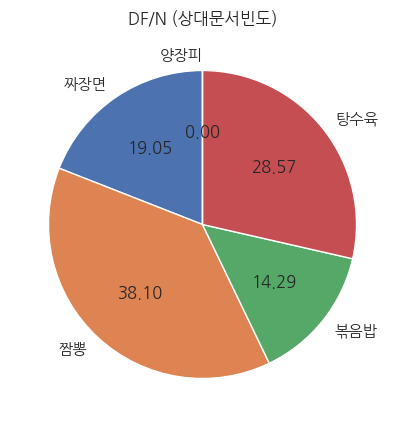

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')

# 총 언급 횟수 벡터
total_vector = reviews.sum(axis=0)
print("총 언급 횟수 벡터:", total_vector)

# 상대도수 벡터
DF_over_N = total_vector / total_vector.sum()
print("상대도수 벡터:", DF_over_N)

# 시각화 (파이 차트)
labels = ['짜장면', '짬뽕', '볶음밥', '탕수육', '양장피']

plt.figure(figsize=(5,5))
plt.pie(DF_over_N, labels=labels, autopct="%.2f", startangle=90)
plt.title("DF/N (상대문서빈도)")
plt.show()

### ***역문서 빈도수 (Inverse Document Frequency, IDF)***

- 특정 단어가 얼마나 희귀한지를 나타내는 지표
- 자주 등장하는 단어는 중요도가 낮고, 드물게 등장하는 단어는 중요도가 높다고 판단

    $
    IDF(t) = \log \frac{N}{DF(t)}
    $

- $(N)$ : 전체 문서 수
- $(DF(t))$ : 단어 $(t)$가 등장한 문서 수

**예시**:  
- 전체 리뷰 수 \(N = 8\)  
- 짬뽕 등장한 문서 수 $(DF(\text{짬뽕}) = 7)$

    $
    IDF(\text{짬뽕}) = \log \frac{8}{7} \approx 0.1335
    $

- 드물게 등장한 음식일수록 IDF 값이 커져 중요도가 상승
```

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')


# 문서 8개, 단어 5개 (짜장면, 짬뽕, 볶음밥, 탕수육, 양장피)
review_vectors = np.array([
    [1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 1, 0, 1, 0],
    [1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0]
])

# 전체 문서 수
N = review_vectors.shape[0]

# 단어별 문서 등장 수
DF = np.count_nonzero(review_vectors, axis=0)

# 역문서 빈도수
IDF = np.log(N / DF)

print("단어별 문서 등장 수 DF:", DF)
print("단어별 역문서 빈도수 IDF:", IDF)

단어별 문서 등장 수 DF: [4 8 3 6 0]
단어별 역문서 빈도수 IDF: [0.69314718 0.         0.98082925 0.28768207        inf]


/tmp/ipykernel_180302/2770181102.py:33: RuntimeWarning: divide by zero encountered in divide
  IDF = np.log(N / DF)


### ***Zero division 방지***
- 스무딩 적용 버전:

    $
    IDF(t) = \log \frac{N}{1 + DF(t)} + 1
    $

- $N$ : 전체 문서 수  
- $DF(t)$ : 단어 $t$가 등장한 문서 수  

- 설명:  
    - $DF(t) = 0$일 때 0으로 나누는 것을 방지  
    - IDF가 0이 되는 것을 방지하기 위해 마지막 +1 추가 가능  
    - 전체 문서 수 $N$에는 +1 하지 않음 (전체 문서 수를 그대로 사용)

단어별 문서 등장 수 DF: [4 8 3 6 0]
스무딩 적용한 IDF: [1.47000363 0.88221696 1.69314718 1.13353139 3.07944154]


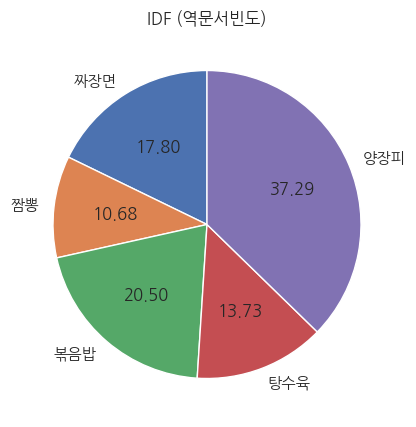

In [9]:
# 역문서 빈도수
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')


# 문서 8개, 단어 5개 (짜장면, 짬뽕, 볶음밥, 탕수육, 양장피)
review_vectors = np.array([
    [1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 1, 0, 1, 0],
    [1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0]
])


# 전체 문서 수
N = review_vectors.shape[0]

# 단어별 문서 등장 수
DF = np.count_nonzero(review_vectors, axis=0)
labels = ["짜장면","짬뽕","볶음밥","탕수육","양장피"]

# 역문서 빈도수
# IDF 스무딩 적용
IDF_smooth = np.log(N / (1 + DF)) + 1
print("단어별 문서 등장 수 DF:", DF)
print("스무딩 적용한 IDF:", IDF_smooth)

plt.figure(figsize=(5,5))
plt.pie(IDF_smooth, labels=labels, autopct="%.2f", startangle=90)
plt.title("IDF (역문서빈도)")
plt.show()

### ***TF-IDF (Term Frequency - Inverse Document Frequency)***
- TF-IDF 수식:

    $
    TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)
    $

- $TF(t, d)$ : 문서 $d$에서 단어 $t$의 등장 횟수  
- $IDF(t)$ : 역문서 빈도수, 단어 $t$가 전체 문서에서 얼마나 드문지 나타냄  

- 설명:  
    - TF는 문서 내에서 단어가 얼마나 자주 나오는지를 나타냄  
    - IDF는 전체 문서에서 단어가 얼마나 희귀한지를 나타냄  
    - TF와 IDF를 곱하면, 특정 문서에서 중요한 단어일수록 값이 커짐

TF (Term Frequency):
 [[1. 1. 1. 1. 0.]
 [0. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 1. 0. 1. 0.]
 [1. 1. 0. 1. 0.]
 [1. 1. 1. 1. 0.]
 [0. 1. 0. 1. 0.]
 [0. 1. 1. 1. 0.]]

DF (Document Frequency):
 [4 8 3 6 0]

IDF (Inverse Document Frequency):
 [1.58778666 1.         1.81093022 1.25131443 3.19722458]

TF-IDF:
 [[1.58778666 1.         1.81093022 1.25131443 0.        ]
 [0.         1.         0.         0.         0.        ]
 [1.58778666 1.         0.         0.         0.        ]
 [0.         1.         0.         1.25131443 0.        ]
 [1.58778666 1.         0.         1.25131443 0.        ]
 [1.58778666 1.         1.81093022 1.25131443 0.        ]
 [0.         1.         0.         1.25131443 0.        ]
 [0.         1.         1.81093022 1.25131443 0.        ]]


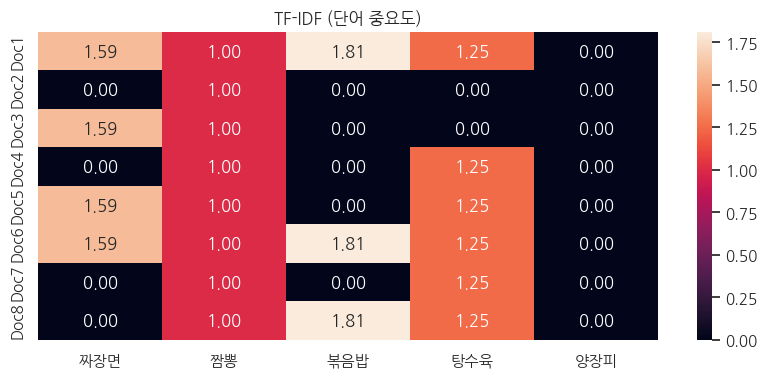

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')

# 리뷰 예제
documents = [
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕이 최고였어요",
    "짜장면도 좋고 짬뽕도 맛있었어요",
    "짬뽕이 맛있고 탕수육도 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요",
    "짬뽕과 탕수육 먹었어요",
    "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
]

# 단어 목록
labels = ["짜장면", "짬뽕", "볶음밥", "탕수육", "양장피"]

# TF 계산 (문서별 단어 등장 횟수)
TF = np.zeros((len(documents), len(labels)))
for i, doc in enumerate(documents):
    for j, w in enumerate(labels):
        TF[i, j] = doc.count(w)

# DF 계산 (문서 빈도수)
DF = np.sum(TF > 0, axis=0)

# IDF 계산 (역문서 빈도수, +1 smoothing)
N = len(documents)
IDF = np.log((N + 1) / (DF + 1)) + 1  # 스무딩

# TF-IDF 계산
TF_IDF = TF * IDF

print("TF (Term Frequency):\n", TF)
print("\nDF (Document Frequency):\n", DF)
print("\nIDF (Inverse Document Frequency):\n", IDF)
print("\nTF-IDF:\n", TF_IDF)

plt.figure(figsize=(10,4))
sns.heatmap(TF_IDF, annot=True, fmt=".2f", xticklabels=labels, yticklabels=[f'Doc{i+1}' for i in range(TF_IDF.shape[0])])
plt.title("TF-IDF (단어 중요도)")
plt.show()

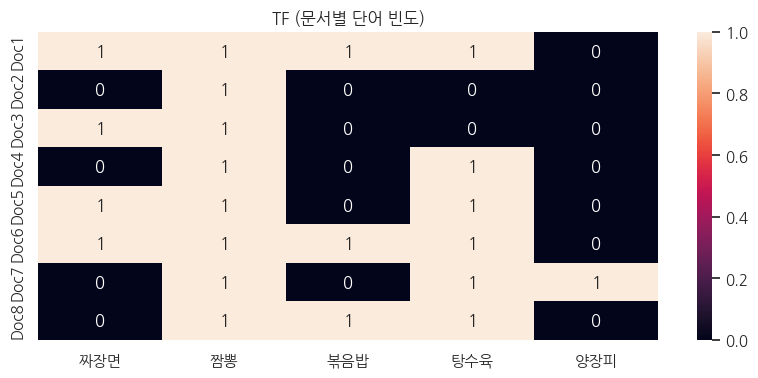

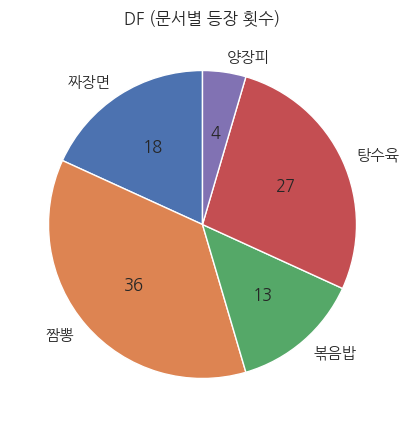

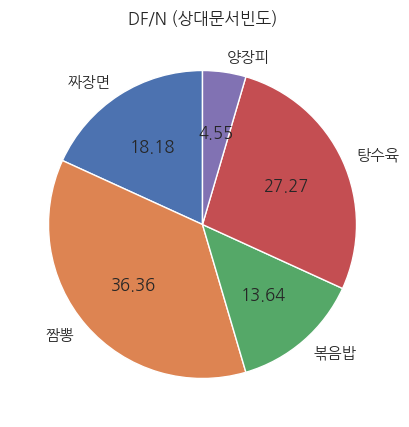

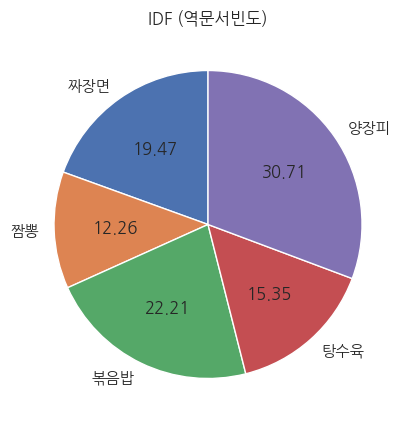

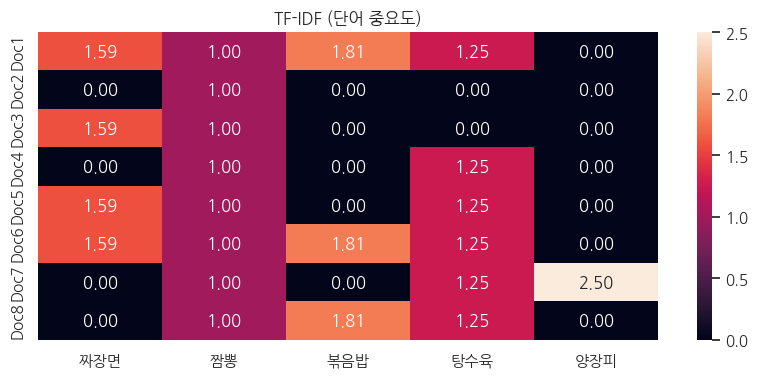

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 설정 (Colab기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')

# 예제 문서 5개, 단어 5개
review_texts = [
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕이 최고였어요",
    "짜장면도 좋고 짬뽕도 맛있었어요",
    "짬뽕이 맛있고 탕수육도 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요",
    "짬뽕과 탕수육 먹었어요", # 수정: 짬뽕과 탕수육하고 양장피도 먹었어요
    "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
]
labels = ["짜장면","짬뽕","볶음밥","탕수육","양장피"]

food_patterns = {
    '짜장면': r'짜장면',
    '짬뽕': r'짬뽕',
    '볶음밥': r'볶음밥',
    '탕수육': r'탕수육',
    '양장피': r'양장피'
}

def review_to_vector(review, patterns):
    vector = [len(re.findall(p, review)) for p in patterns.values()]
    return vector

# 모든 리뷰를 벡터로 변환
review_vectors = np.array([review_to_vector(r, food_patterns) for r in review_texts])

# TF 계산
TF = np.zeros((len(documents), len(labels)))
for i, doc in enumerate(documents):
    for j, w in enumerate(labels):
        TF[i, j] = doc.count(w)

# DF 계산 (단어별 등장 문서 수)
DF = np.count_nonzero(TF, axis=0)

# 상대문서빈도 DF/N
N = len(documents)
DF_over_N = DF / N

# IDF 계산 (smoothed)
IDF = np.log((N+1)/(DF+1)) + 1

# TF-IDF 계산
TF_IDF = TF * IDF

# 1. TF 히트맵
plt.figure(figsize=(10,4))
sns.heatmap(TF.astype(int), annot=True, fmt="d", xticklabels=labels, yticklabels=[f'Doc{i+1}' for i in range(TF.shape[0])])
plt.title("TF (문서별 단어 빈도)")
plt.show()

# 2. DF 파이차트
plt.figure(figsize=(5,5))
plt.pie(DF, labels=labels, autopct="%d", startangle=90)
plt.title("DF (문서별 등장 횟수)")
plt.show()

# 3. DF/N 파이차트
plt.figure(figsize=(5,5))
plt.pie(DF_over_N, labels=labels, autopct="%.2f", startangle=90)
plt.title("DF/N (상대문서빈도)")
plt.show()

# 4. IDF 파이차트
plt.figure(figsize=(5,5))
plt.pie(IDF, labels=labels, autopct="%.2f", startangle=90)
plt.title("IDF (역문서빈도)")
plt.show()

# 5. TF-IDF 히트맵
plt.figure(figsize=(10,4))
sns.heatmap(TF_IDF, annot=True, fmt=".2f", xticklabels=labels, yticklabels=[f'Doc{i+1}' for i in range(TF_IDF.shape[0])])
plt.title("TF-IDF (단어 중요도)")
plt.show()